<a href="https://colab.research.google.com/github/Bastien-PZ/Cours_Python_BSSAF/blob/main/percolation_tp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
# pour faire une belle forêt
colors = ['blue', 'white', 'brown']
cmap = ListedColormap(colors)
bounds = [-2, -0.5, .5, 2]
norm = BoundaryNorm(bounds, cmap.N)

rng = np.random.default_rng()

On commence par initialiser le café :

In [104]:
taille = 500

In [121]:
cafe = rng.binomial(n=1, p=.53, size=(taille, taille))
# je rajoute une bande autour pour faciliter les calculs
cafe = np.pad(cafe, 1, constant_values=0)

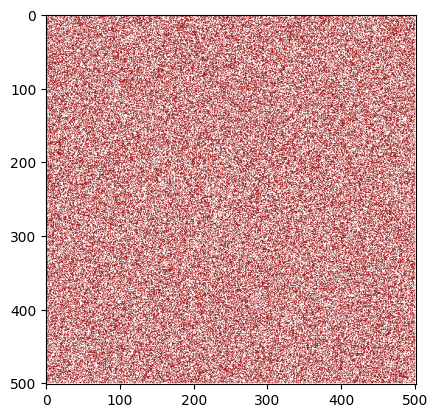

In [122]:
plt.imshow(cafe, cmap=cmap, norm=norm)

L'eau tombe par le haut, on va remplacer la première ligne avec des -1

In [123]:
cafe[1,:] = -1 * cafe[1,:]

In [124]:
cafe

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0, -1,  0, ..., -1, -1,  0],
       [ 0,  0,  1, ...,  0,  0,  0],
       ...,
       [ 0,  0,  1, ...,  0,  0,  0],
       [ 0,  1,  0, ...,  1,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]])

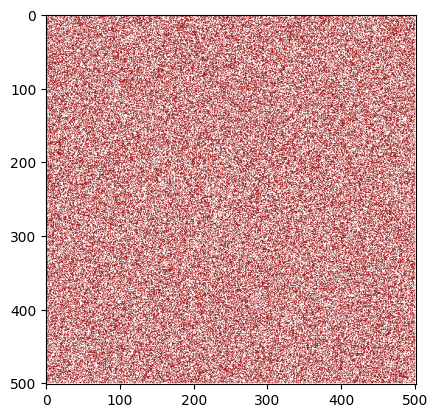

In [125]:
plt.imshow(cafe, cmap=cmap, norm=norm)

On va faire tomber l'eau juste en dessous

In [126]:
potentiel = np.concat([[False], ((cafe[1,0:(taille)]==-1) | (cafe[1,1:(taille+1)]==-1) | (cafe[1,2:(taille+2)]==-1)), [False]] )

In [127]:
potentiel

array([False,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [128]:
cafe[2,potentiel] = -1 * cafe[2, potentiel]

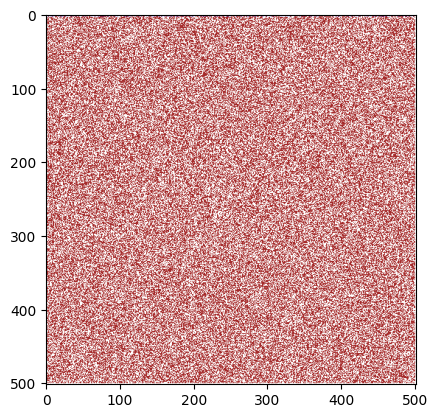

In [129]:
plt.imshow(cafe, cmap=cmap, norm=norm)

Faire une fonction pour descendre l'eau d'une ligne

In [130]:
def tomber_eau(cafe, i):
  potentiel = np.concat([[False], ((cafe[i,0:(taille)]==-1) | (cafe[i,1:(taille+1)]==-1) | (cafe[i,2:(taille+2)]==-1)), [False]] )
  cafe[i+1,potentiel] = -1 * cafe[i+1, potentiel]

Peux tu l'appliquer sur l'ensemble de la cafetière successivement. Est ce que l'eau touche le bas de la cafetière ?

In [131]:
for i in range(2, taille):
  tomber_eau(cafe,i)

In [132]:
cafe[taille,:].sum()<0

np.False_

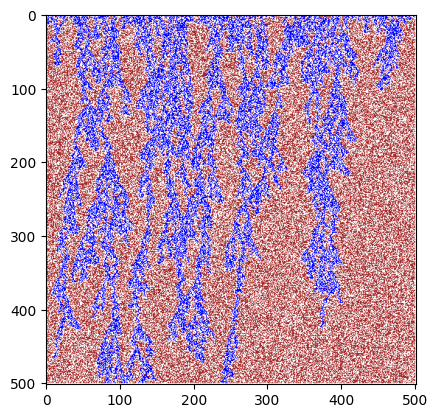

In [133]:
plt.imshow(cafe, cmap=cmap, norm=norm)

Maintenant, on va estimer le coefficient de percolation, pour ce faire on va boucler sur les probabilités et pour consolider les résultats, on va répéter l'expérience 100 fois par probabilité

In [118]:
def make_cafe(p, taille):
   cafe = rng.binomial(n=1, p=p, size=(taille, taille))
   cafe = np.pad(cafe, 1, constant_values=0)
   cafe[1,:] = -1 * cafe[1,:]
   for k in range(1, taille):
      tomber_eau(cafe, k)
   return(cafe[taille,:].sum()<0)

make_cafe(0.3, taille)

np.False_

In [119]:
ps = np.arange(0,1,0.01)
stat = np.zeros(len(ps))
for i, p in enumerate(ps):
   stat[i] = np.mean([make_cafe(p, taille) for j in range(100)])

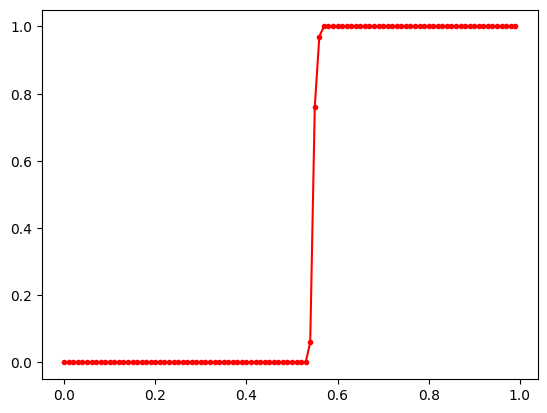

In [120]:
plt.plot(ps, stat, '.r-')